# Checkpoint 39: Feature Diagnostics

This notebook reviews redundancy, reference-category encoding, VIF, condition number, and employee-cluster bootstrap coefficient stability. Target-informed results use only the 2023 and 2024 development snapshots.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [2]:
inventory = pd.read_csv(PROCESSED_DIR / "feature_diagnostics.csv")
numeric = pd.read_csv(PROCESSED_DIR / "numeric_correlation_diagnostics.csv")
categorical = pd.read_csv(PROCESSED_DIR / "categorical_association_diagnostics.csv")
vif = pd.read_csv(PROCESSED_DIR / "vif_diagnostics.csv")
condition = pd.read_csv(PROCESSED_DIR / "condition_number_diagnostics.csv")
manifest = pd.read_csv(PROCESSED_DIR / "encoded_feature_manifest.csv")
coefficients = pd.read_csv(PROCESSED_DIR / "coefficient_stability.csv")
checks = pd.read_csv(PROCESSED_DIR / "feature_policy_validation.csv")
bootstrap = pd.read_csv(PROCESSED_DIR / "bootstrap_run_summary.csv")

## Validation checks

Every check should show `PASS`. The reserved 2025 target usage should equal zero.

In [3]:
checks

,check,status,observed,requirement,details
0,Every dataset column has a policy,PASS,52,52,Unassigned=[]; unknown=[]
1,Policy groups do not overlap,PASS,[],No overlap,"Metadata, selected, and dropped groups are exc..."
2,Selected features exist,PASS,[],No missing selected features,Every selected feature must exist in the panel.
3,Reference categories exist,PASS,All present,Every reference appears in development data,The first configured category is omitted by en...
4,Model population uses outcome-eligible levels,PASS,"['Individual Contributor', 'Team Manager']","['Individual Contributor', 'Team Manager']",Protected hierarchy levels remain in workforce...
5,Development snapshots are exact,PASS,"['2023-06-30', '2024-06-30']","['2023-06-30', '2024-06-30']",Only development periods may inform the featur...
6,Reserved holdout remains unused,PASS,6641 reserved rows; 0 target rows used,Holdout exists and target usage equals 0,The 2025 outcomes remain untouched for later f...
7,Encoded feature names are unique,PASS,35,35 unique names,Every model coefficient must map to one encode...
8,Encoded matrix has full column rank,PASS,35,35,Reference encoding must remove exact dummy-var...
9,Maximum VIF is acceptable,PASS,3.9502,<= 5.0,Selected encoded columns should avoid severe m...


## Complete feature policy

In [4]:
inventory.groupby(["decision", "role"], as_index=False).size()

,decision,role,size
0,DROP,Redundant or unsuitable feature,25
1,EXCLUDE,Metadata,5
2,KEEP,Categorical model feature,6
3,KEEP,Numerical model feature,15
4,TARGET,Outcome,1


In [5]:
inventory[["feature", "decision", "role", "reason"]]

,feature,decision,role,reason
0,employee_id,EXCLUDE,Metadata,"Retained for auditing or splitting, not model ..."
1,dataset_type,EXCLUDE,Metadata,"Retained for auditing or splitting, not model ..."
2,snapshot_sequence,EXCLUDE,Metadata,"Retained for auditing or splitting, not model ..."
3,snapshot_date,EXCLUDE,Metadata,"Retained for auditing or splitting, not model ..."
4,prediction_end_date,EXCLUDE,Metadata,"Retained for auditing or splitting, not model ..."
5,approx_age,KEEP,Numerical model feature,Retained after semantic and statistical redund...
6,tenure_years,KEEP,Numerical model feature,Retained after semantic and statistical redund...
7,employment_type,DROP,Redundant or unsuitable feature,Exactly determined by job level in the Version...
8,education_level,KEEP,Categorical model feature,"Retained with ""Bachelor's"" as its reference ca..."
9,organizational_level,KEEP,Categorical model feature,Retained with 'Individual Contributor' as its ...


## Strongest original numeric correlations

These candidate-feature relationships explain why several raw columns were removed.

In [6]:
(
    numeric.loc[numeric["stage"].eq("candidate")]
    .sort_values("absolute_correlation", ascending=False)
    .head(15)
)

,stage,first_feature,second_feature,correlation,absolute_correlation,above_threshold
0,candidate,days_since_compensation_change,days_since_review,1.000000,1.000000,True
1,candidate,promotion_compensation_count,prior_promotion_events,1.000000,1.000000,True
2,candidate,initial_base_salary,base_salary,0.984823,0.984823,True
3,candidate,performance_rating,average_performance_rating,0.980018,0.980018,True
4,candidate,promotion_compensation_count,no_prior_promotion,-0.977156,0.977156,True
5,candidate,prior_promotion_events,no_prior_promotion,-0.977156,0.977156,True
6,candidate,tenure_years,compensation_record_count,0.952727,0.952727,True
7,candidate,salary_growth_percent,compensation_record_count,0.899730,0.899730,True
8,candidate,review_count,no_prior_review,-0.869047,0.869047,True
9,candidate,base_salary,equity_value,0.864111,0.864111,True


## Strongest original categorical associations

In [7]:
categorical.head(15)

,first_feature,second_feature,corrected_cramers_v,first_cardinality,second_cardinality
0,city,region,0.999949,5,4
1,city,location_type,0.999949,5,4
2,department_name,department_group,0.999794,8,4
3,job_title,job_family,0.999485,20,10
4,job_title,job_level,0.999177,20,4
5,employment_type,job_title,0.960667,2,20
6,organizational_level,job_title,0.959240,2,20
7,employment_type,job_level,0.957075,2,4
8,department_group,job_title,0.922210,4,20
9,department_name,job_title,0.877717,8,20


## Variance inflation factors

The policy requires every encoded VIF to remain at or below 5.

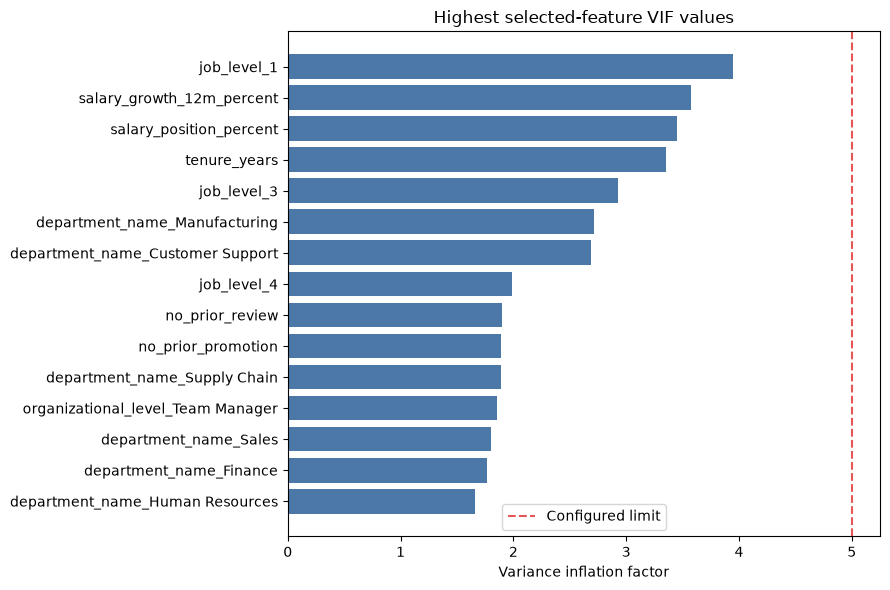

In [8]:
top_vif = vif.head(15).sort_values("vif")

plt.figure(figsize=(9, 6))
plt.barh(top_vif["encoded_feature"], top_vif["vif"], color="#4C78A8")
plt.axvline(5.0, color="#E45756", linestyle="--", label="Configured limit")
plt.xlabel("Variance inflation factor")
plt.title("Highest selected-feature VIF values")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
condition

,metric,value,requirement
0,Development rows,9727,> 0
1,Raw selected features,21,Policy defined
2,Encoded features,35,Unique encoded columns
3,Matrix rank,35,35
4,Condition number,5.290241030429106,<= 30.0
5,Maximum VIF,3.9501603823733524,<= 5.0
6,VIF matrix method,inverse,inverse preferred


## Reference-category manifest

Each categorical coefficient compares one displayed category with its omitted reference category.

In [10]:
manifest

,encoded_feature,source_feature,feature_type,category,reference_category,coefficient_comparison
0,approx_age,approx_age,Numerical,NaN,NaN,One standard-deviation increase after imputation
1,tenure_years,tenure_years,Numerical,NaN,NaN,One standard-deviation increase after imputation
2,salary_growth_12m_percent,salary_growth_12m_percent,Numerical,NaN,NaN,One standard-deviation increase after imputation
3,salary_position_percent,salary_position_percent,Numerical,NaN,NaN,One standard-deviation increase after imputation
4,days_since_compensation_change,days_since_compensation_change,Numerical,NaN,NaN,One standard-deviation increase after imputation
5,performance_rating,performance_rating,Numerical,NaN,NaN,One standard-deviation increase after imputation
6,performance_trend,performance_trend,Numerical,NaN,NaN,One standard-deviation increase after imputation
7,no_prior_review,no_prior_review,Numerical,NaN,NaN,One standard-deviation increase after imputation
8,completed_training_hours_12m,completed_training_hours_12m,Numerical,NaN,NaN,One standard-deviation increase after imputation
9,failed_training_programs_12m,failed_training_programs_12m,Numerical,NaN,NaN,One standard-deviation increase after imputation


## Employee-cluster bootstrap coefficient stability

Only directions whose 95% bootstrap interval excludes zero and whose sign stability is at least 90% are displayed. These are predictive associations, not causal effects.

In [11]:
stable = coefficients.loc[
    coefficients["reportable_direction"].astype(bool)
].copy()
stable[
    [
        "encoded_feature",
        "bootstrap_median",
        "bootstrap_lower_95",
        "bootstrap_upper_95",
        "sign_stability",
        "direction",
    ]
]

,encoded_feature,bootstrap_median,bootstrap_lower_95,bootstrap_upper_95,sign_stability,direction
0,job_level_4,-0.878077,-1.592817,-0.325410,0.990,Lower predicted attrition risk
1,education_level_Doctorate,-0.512974,-0.927804,-0.080222,0.995,Lower predicted attrition risk
2,department_name_Customer Support,0.442263,0.063043,0.830485,0.985,Higher predicted attrition risk
3,salary_position_percent,-0.418571,-0.576841,-0.280376,1.000,Lower predicted attrition risk
4,performance_rating,-0.264395,-0.346524,-0.185105,1.000,Lower predicted attrition risk
5,job_level_3,-0.262461,-0.476430,-0.021564,0.985,Lower predicted attrition risk
6,education_level_Associate,-0.252958,-0.460702,-0.072075,0.985,Lower predicted attrition risk
10,no_prior_review,-0.139880,-0.261468,-0.042378,1.000,Lower predicted attrition risk
23,prior_transfer_events,0.053883,0.003913,0.114145,0.975,Higher predicted attrition risk


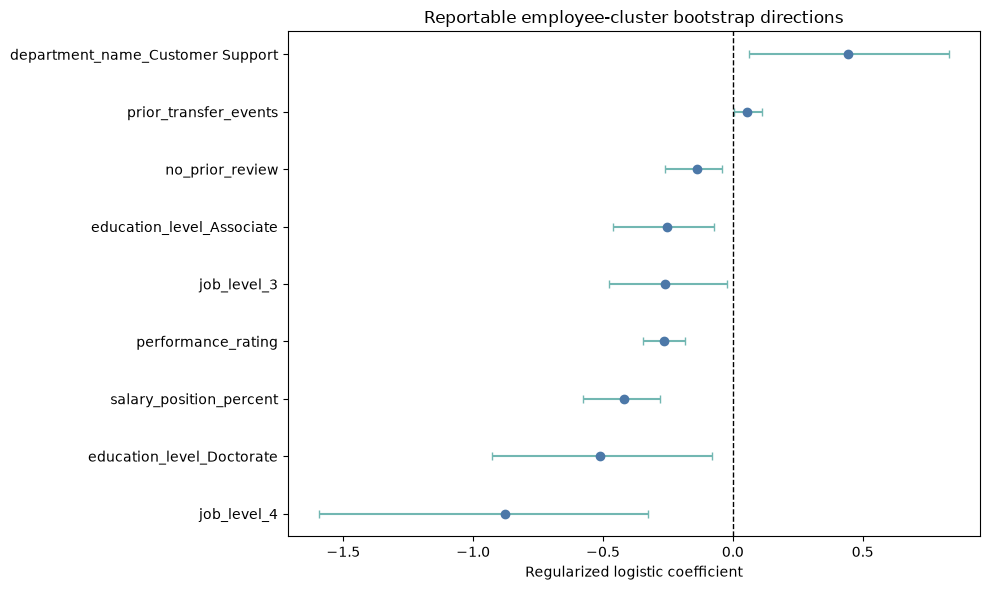

In [12]:
plot_data = stable.sort_values("bootstrap_median")
lower_error = plot_data["bootstrap_median"] - plot_data["bootstrap_lower_95"]
upper_error = plot_data["bootstrap_upper_95"] - plot_data["bootstrap_median"]

plt.figure(figsize=(10, 6))
plt.errorbar(
    plot_data["bootstrap_median"],
    plot_data["encoded_feature"],
    xerr=[lower_error, upper_error],
    fmt="o",
    color="#4C78A8",
    ecolor="#72B7B2",
    capsize=3,
)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Regularized logistic coefficient")
plt.title("Reportable employee-cluster bootstrap directions")
plt.tight_layout()
plt.show()

## Bootstrap scope

In [13]:
bootstrap

,metric,value
0,Development snapshots,"2023-06-30, 2024-06-30"
1,Development rows,9727
2,Unique employee clusters,5935
3,Positive cases,1000
4,Bootstrap iterations,200
5,Bootstrap attempts,200
6,Encoded coefficients,35
7,Reportable coefficient directions,9
8,Reserved holdout target rows used,0


## Conclusion

The selected reference-encoded matrix is full rank, has acceptable VIF and condition number, and preserves the 2025 holdout. Coefficient stability is treated as predictive evidence only. Checkpoint 40 will define the train, validation, and test periods.